<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Rain gauge optimisation
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p>This code works on defining optimal locations for placements of new rain gauges in the Upper Severn catchment. The placement of the gauges aims to optimise the accuracy with which rainfall over the catchment can be predicted. </p>

  <p><strong>The following data is available:</strong></p>
  <ul>
    <li> 1km HAD-UK gridded annual (?) rainfall data </li>
    <li> Rain gauge data from 10? existing rain gauges</li>
    <li> 30m (?) DEM data: from which slope and aspect can be derived. These are then aggregated to 1km </li>      
  </ul>
<!-- 
  <div style="background-color: white; border-left: 4px solid orange; 
  padding: 8px 15px; border-radius: 0px 5px 5px 0px; margin-top: 12px;">
    <strong>NB:</strong> The threshold for an "unphysical" value is 
    currently set at <strong>150mm/hr</strong> — selected relatively 
    arbitrarily and may need review.
  </div> -->

</div>

In [2]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr
from pathlib import Path
from rasterio.features import rasterize
from shapely.geometry import box

data_dir = "/scratch/hydro4/users/kv25483/FDRI/Rain_gauge_optimisation/Data/"
catchment_Dolwen = gpd.read_file(data_dir + "54080/54080.shp")

### Get gridded rainfall data

In [3]:
HAD_names = sorted(Path(data_dir + "HAD_rainfall_annual/").glob("*.nc"))
HAD_layers = [xr.open_dataset(f) for f in HAD_names]
HAD_ann = xr.concat([ds['rainfall'] for ds in HAD_layers], dim="time")

HAD_ann = HAD_ann.rio.write_crs("EPSG:27700")
HAD_Dolwen_ppn = HAD_ann.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs,drop=True, all_touched=True)
HAD_Dolwen_ppn_mean = HAD_Dolwen_ppn.mean(dim="time")

In [4]:
ceh_on_had = xr.open_dataset ("Data/ceh_on_had.nc")['rainfall_amount']
ceh_on_had = ceh_on_had.rio.write_crs("EPSG:27700")
ceh_on_had = ceh_on_had.rio.clip(catchment_Dolwen.geometry, crs=catchment_Dolwen.crs,drop=True, all_touched=True)
ceh_on_had_mean = ceh_on_had.mean(dim="time")
ceh_on_had_max = ceh_on_had.max(dim="time")

In [5]:
import os
os.listdir(data_dir + "HAD_rainfall_annual/")
import glob
import pandas as pd
import netCDF4

In [6]:
# def get_cehgear_at_gauge (filenames, rain_gauge_name):
    
#     # Extract the single point FIRST (cheap)
#     rain_gauge_data = rain_meta_sf[rain_meta_sf['station_name']==rain_gauge_name]
    
#     x_val = float(rain_gauge_data['x'].iloc[0])
#     y_val = float(rain_gauge_data['y'].iloc[0])

#     # Find your x,y indices from the first file only
#     with netCDF4.Dataset(filenames[0]) as nc:
#         x_coord = nc.variables['projection_x_coordinate'][:]
#         y_coord = nc.variables['projection_y_coordinate'][:]
#         x_idx = np.abs(x_coord - x_val).argmin()
#         y_idx = np.abs(y_coord - y_val).argmin()

#     # Read just that pixel from every file
#     all_data = []
#     all_times = []

#     for f in sorted(filenames):
#         with netCDF4.Dataset(f) as nc:
#             data = nc.variables['rainfall'][:, y_idx, x_idx]  # (time,)
#             data = np.where(data == -999.0, np.nan, data)
#             data = np.where(data == -9999, np.nan, data)
#             data = np.where(data < 0, np.nan, data)

#             times = netCDF4.num2date(nc.variables['time'][:], nc.variables['time'].units)
#             all_data.append(data)
#             all_times.extend(times)

#     # Combine
#     rainfall = np.concatenate(all_data)
#     times = np.array(all_times)

#     # Build dataframe and aggregate
#     df = pd.DataFrame({ 'time': times, 'rainfall': rainfall})
#     df['date'] = pd.to_datetime([t.strftime('%Y-%m-%d %H:%M:%S') for t in df['time']])
#     df['year'] = df['date'].dt.year
#     df['date_only'] = df['date'].dt.date

#     # Daily totals, then annual mean daily
#     annual_hourly_mean = df.groupby('year')['rainfall'].mean().reset_index()
#     annual_hourly_mean.columns = ['year', 'mean_daily_rainfall_mm']
#     #annual_daily_mean = daily_totals.groupby('year')['rainfall'].mean().reset_index()
#     #annual_daily_mean.columns = ['year', 'mean_hourly_rainfall_mm']

#     annual_total = df.groupby('year')['rainfall'].sum().reset_index()
#     annual_total.columns = ['year', 'total_rainfall_mm']
#     return annual_total

In [7]:
# ceh_gear_dir = data_dir + "HAD_rainfall_annual/"
# filenames=[]
# for year in range(1990,2017):
#     general_filename = ceh_gear_dir + f'rainfall_hadukgrid_uk_1km_ann_{year}*'
#     for filename in glob.glob(general_filename):
#         filenames.append(filename)

# # Load rain gauge metadata
# rain_meta_cmd = pd.read_csv(data_dir + "rain_meta_for_CMD.csv")

# # Convert to GeoDataFrame (BNG coordinates)
# rain_meta_sf = gpd.GeoDataFrame(rain_meta_cmd, geometry=gpd.points_from_xy(rain_meta_cmd["x_2"], rain_meta_cmd["y_2"]),
#                                 crs="EPSG:27700")        
        
# DOLYDD_df = get_cehgear_at_gauge(filenames, 'DOLYDD')
# DOLYDD_df

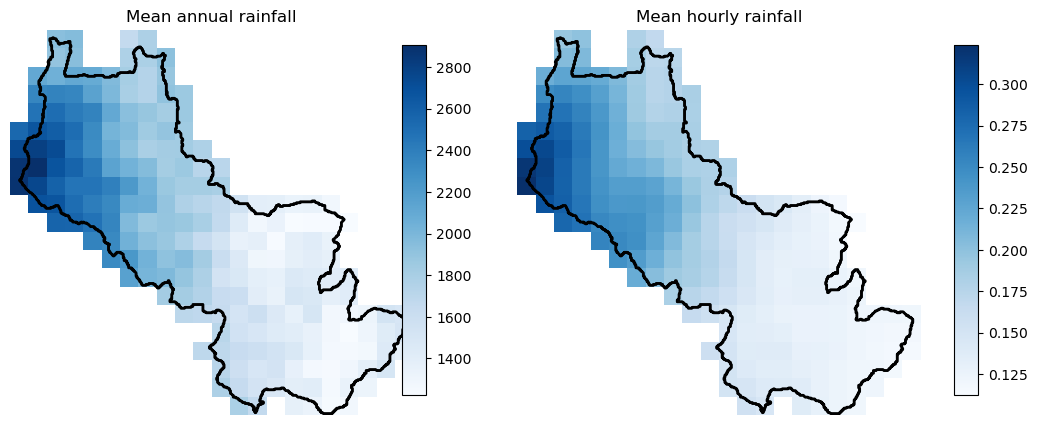

In [8]:
fig, axs = plt.subplots(ncols=2, figsize=(12,5))

p1 = HAD_Dolwen_ppn_mean.plot(cmap='Blues', ax=axs[0], add_colorbar=False)
p2 = ceh_on_had_mean.plot(cmap='Blues', ax=axs[1], add_colorbar=False)

for ax in axs:
    catchment_Dolwen.boundary.plot(ax=ax, color="black")
    catchment_Dolwen.plot(ax=ax, color='none', edgecolor='black', linewidth=2)
    ax.axis('off')
    
axs[0].set_title("Mean annual rainfall")
axs[1].set_title("Mean hourly rainfall")

# Create colorbar axes manually (same height!)
cax1 = fig.add_axes([0.46, 0.15, 0.02, 0.7])
cax2 = fig.add_axes([0.92, 0.15, 0.02, 0.7])

fig.colorbar(p1, cax=cax1)
fig.colorbar(p2, cax=cax2)

plt.show()

In [9]:
rainfall_df = HAD_Dolwen_ppn_mean.to_dataframe(name="rainfall").reset_index()
rainfall_df = rainfall_df.dropna(subset=["rainfall"])
rainfall_df.rename(columns = {'rainfall':'mean_annual_rainfall'}, inplace=True)

In [10]:
rainfall_df2 = ceh_on_had_mean.to_dataframe(name="rainfall").reset_index()
rainfall_df2 = rainfall_df2.dropna(subset=["rainfall"])
rainfall_df2.rename(columns = {'rainfall':'mean_daily_rainfall'}, inplace=True)

rainfall_df3 = ceh_on_had_max.to_dataframe(name="rainfall").reset_index()
rainfall_df3 = rainfall_df3.dropna(subset=["rainfall"])
rainfall_df3.rename(columns = {'rainfall':'max_daily_rainfall'}, inplace=True)

In [11]:
# rainfall_merged = rainfall_df.merge(rainfall_df2,on=["projection_x_coordinate", "projection_y_coordinate"],how="inner",
#                            suffixes=("", "_drop"))

# # Drop duplicates
# rainfall_merged = rainfall_merged.drop(columns=[col for col in rainfall_merged.columns if col.endswith("_drop")])

In [12]:
from functools import reduce

common_cols = ["projection_x_coordinate", "projection_y_coordinate"]

def merge_func(left, right):
    merged = left.merge(right,on=common_cols,how="inner",suffixes=("", "_drop"))
    
    # Find columns to drop
    drop_cols = [c for c in merged.columns if c.endswith("_drop")]
    
    return merged.drop(columns=drop_cols)

rainfall_merged = reduce(merge_func, [rainfall_df, rainfall_df2, rainfall_df3])

In [13]:
rainfall_gdf = gpd.GeoDataFrame(rainfall_merged, geometry=gpd.points_from_xy(rainfall_merged.projection_x_coordinate,
                                rainfall_merged.projection_y_coordinate), crs="EPSG:27700")
rainfall_gdf = rainfall_gdf.drop(columns=['transverse_mercator', 'spatial_ref'], axis=1)

# Create polygons based on the mid points of the cells
half = 500
rainfall_gdf["geometry"] = [ box(x - half, y - half, x + half, y + half)
    for x, y in zip(rainfall_gdf["projection_x_coordinate"], rainfall_gdf["projection_y_coordinate"])]

In [14]:
# plt.scatter(rainfall_merged['mean_daily_rainfall'], rainfall_merged['max_daily_rainfall'])
# plt.xlabel('Elevation')
# plt.xlabel('Rainfall');

### Get terrain data (DEM and then derive slope and aspect)

In [15]:
# Define location of DEM
dem_path = data_dir + "dem_Dolwen.tif"

# 1. Load DEM
with rioxarray.open_rasterio(dem_path, masked=True) as dem_rx:
    dem = dem_rx.squeeze()
    dem_arr = dem.values.astype(float)
    transform = dem.rio.transform()

# 2. Get grid resolution    
dx = transform.a   # pixel width
dy = -transform.e  # pixel height (positive)    

# 3. Compute slope + aspect (drop-in replacement)
dz_dy, dz_dx = np.gradient(dem_arr, dy, dx)

# Slope (degrees)
slope_arr = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

# Aspect (degrees, 0–360)
aspect_arr = np.degrees(np.arctan2(-dz_dx, dz_dy))
aspect_arr = np.where(aspect_arr < 0, 360 + aspect_arr, aspect_arr)

#from scipy.ndimage import generic_filter

# def tri_func(window):
#     center = window[len(window)//2]
#     return np.mean(np.abs(window - center))

# tri_arr = generic_filter(dem_arr, tri_func, size=3)

In [16]:
slope_1 = dem.copy()
slope_1.data = slope_arr

aspect_1 = dem.copy()
aspect_1.data = aspect_arr

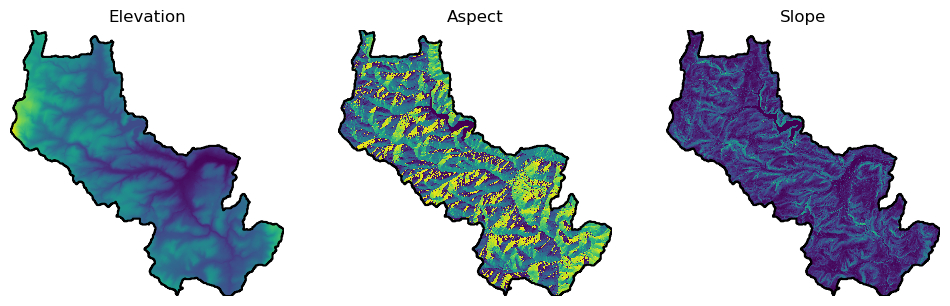

In [17]:
fig, axs = plt.subplots(ncols = 3, figsize=(12,4))
dem.plot(ax=axs[0], add_colorbar=False)
catchment_Dolwen.boundary.plot(ax=axs[0], color="black")     
axs[0].axis('off');
axs[0].set_title('Elevation');

aspect_1.plot(ax=axs[1], add_colorbar=False)
catchment_Dolwen.boundary.plot(ax=axs[1], color="black")     
axs[1].axis('off');
axs[1].set_title('Aspect');

slope_1.plot(ax=axs[2], add_colorbar=False)
catchment_Dolwen.boundary.plot(ax=axs[2], color="black")     
axs[2].axis('off');
axs[2].set_title('Slope');

### Summarise slope/aspect/elevation inside each 1km grid cell

Could this just be done with regridding?

In [18]:
# Step 1: Give each pixel an ID
rainfall_gdf["zone_id"] = np.arange(len(rainfall_gdf))

# Step 2: Rasterise polygons, so each pixel stores its grid ID
zone_raster = rasterize([(geom, value) for geom, value in zip(rainfall_gdf.geometry, rainfall_gdf.zone_id)],
    out_shape=dem_arr.shape,transform=transform,fill=-1, dtype="int32")

# Step 3: Convert to xarray (so zone map is an xarray object, same shape as the DEM, slope and aspect)
zones = xr.DataArray(zone_raster, dims=("y", "x"))
dem_xr = xr.DataArray(dem_arr, dims=("y", "x"))
slope_xr = xr.DataArray(slope_arr, dims=("y", "x"))
aspect_xr = xr.DataArray(aspect_arr, dims=("y", "x"))

# Step 4: Mask out irrelevant pixels
mask = zones >= 0
zones = zones.where(mask)
dem_xr = dem_xr.where(mask)
slope_xr = slope_xr.where(mask)
aspect_xr = aspect_xr.where(mask)

# Group all DEM pixels by their zone_id (Split the DEM into groups, where each group contains all
# pixels that belong to the same grid cell (zone_id).)
dem_stats = dem_xr.groupby(zones)

# # Step 6: Compute stats
### Elevation
dem_df = xr.Dataset({"mean_dem": dem_stats.mean(), "min_dem": dem_stats.min(),"max_dem": dem_stats.max(),  
                     "std_dem": dem_stats.std()}).to_dataframe()

#### Slope
slope_df = xr.Dataset({"mean_slope": slope_xr.groupby(zones).mean(),
    "std_slope": slope_xr.groupby(zones).std()}).to_dataframe()

### Aspect
aspect_df = xr.Dataset({"mean_aspect": aspect_xr.groupby(zones).mean(),
    "std_aspect": aspect_xr.groupby(zones).std()}).to_dataframe()

### Plot at 1km

Text(0.5, 1.0, 'Slope (1km)')

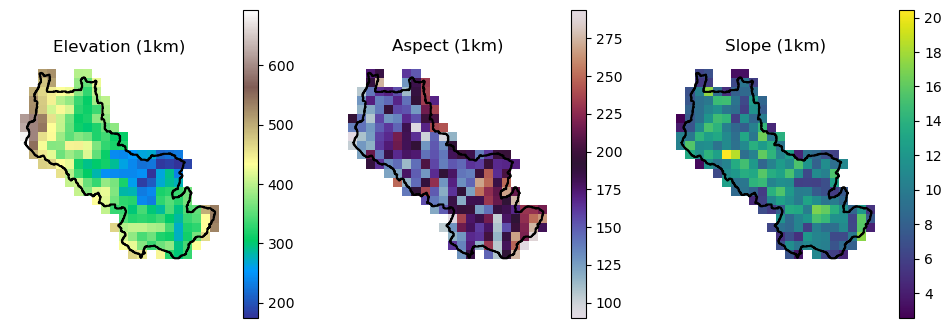

In [20]:
# Step 5: Combine zonal stats back onto the 1km grid geometry
# (check the index name produced by groupby first — it may be 'group' rather than 'zone_id')
dem_df.index.name  # inspect this

zonal_stats = dem_df.join(slope_df).join(aspect_df).reset_index()
zonal_stats = zonal_stats.rename(columns={zonal_stats.columns[0]: "zone_id"})

rainfall_gdf_stats = rainfall_gdf.merge(zonal_stats, on="zone_id", how="left")

# Step 6: Plot at 1km resolution
fig, axs = plt.subplots(ncols=3, figsize=(12, 4))

rainfall_gdf_stats.plot(column="mean_dem", ax=axs[0], legend=True, cmap="terrain")
catchment_Dolwen.boundary.plot(ax=axs[0], color="black")
axs[0].axis('off'); axs[0].set_title('Elevation (1km)')

rainfall_gdf_stats.plot(column="mean_aspect", ax=axs[1], legend=True, cmap="twilight")
catchment_Dolwen.boundary.plot(ax=axs[1], color="black")
axs[1].axis('off'); axs[1].set_title('Aspect (1km)')

rainfall_gdf_stats.plot(column="mean_slope", ax=axs[2], legend=True, cmap="viridis")
catchment_Dolwen.boundary.plot(ax=axs[2], color="black")
axs[2].axis('off'); axs[2].set_title('Slope (1km)')

### Contain one dataset which includes all of the variables for each 1km grid cell within the catchment

In [25]:
rainfall_gdf.reset_index(inplace=True, drop=True)
rainfall_gdf_merged = (rainfall_gdf
        .merge(dem_df, left_index=True, right_index=True)
          .merge(aspect_df, left_index=True, right_index=True)
          .merge(slope_df,  left_index=True, right_index=True))

rainfall_gdf_merged["aspect_sin"] = np.sin(np.deg2rad(rainfall_gdf_merged["mean_aspect"]))
rainfall_gdf_merged["aspect_cos"] = np.cos(np.deg2rad(rainfall_gdf_merged["mean_aspect"]))

### Keep only cells with a substantial portion of cell within catchment

In [ ]:
# rainfall_gdf_merged["cell_area"] = rainfall_gdf_merged.geometry.area

# intersection = gpd.overlay(rainfall_gdf_merged,catchment_Dolwen[["geometry"]],how="intersection")

# intersection["intersect_area"] = intersection.geometry.area

# rainfall_gdf_merged = rainfall_gdf_merged.merge(intersection.groupby(intersection.index)["intersect_area"].sum(),
#                                                 left_index=True,right_index=True,how="left")

# rainfall_gdf_merged["intersect_area"] = rainfall_gdf_merged["intersect_area"].fillna(0)
# rainfall_gdf_merged["coverage"] = rainfall_gdf_merged["intersect_area"] / rainfall_gdf_merged["cell_area"]

# rainfall_gdf_merged = rainfall_gdf_merged[rainfall_gdf_merged["coverage"] >= 0.5]
# rainfall_gdf_merged = rainfall_gdf_merged[rainfall_gdf_merged['intersect_area']>100000].copy()
# rainfall_gdf_merged.reset_index(inplace=True, drop=True)

### Save to file

In [26]:
rainfall_gdf_merged.to_file(data_dir+ "Derived/rainfall_gdf_merged.gpkg", driver="GPKG")
rainfall_gdf_merged.columns

Index(['projection_y_coordinate', 'projection_x_coordinate', 'latitude',
       'longitude', 'mean_annual_rainfall', 'mean_daily_rainfall',
       'max_daily_rainfall', 'geometry', 'zone_id', 'mean_dem', 'min_dem',
       'max_dem', 'std_dem', 'mean_aspect', 'std_aspect', 'mean_slope',
       'std_slope', 'aspect_sin', 'aspect_cos'],
      dtype='object')

### Check on relationships

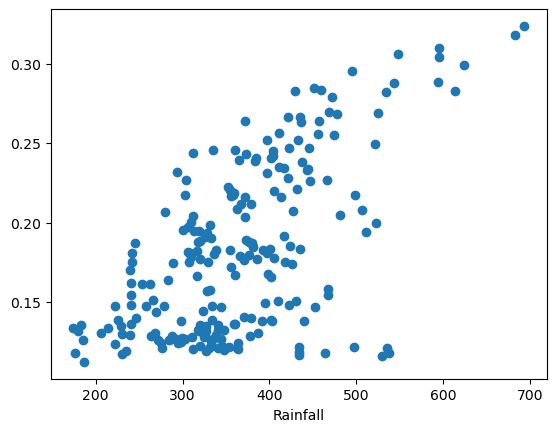

In [29]:
plt.scatter(rainfall_gdf_merged['mean_dem'], rainfall_gdf_merged['mean_daily_rainfall'])
plt.xlabel('Elevation')
plt.xlabel('Rainfall');